In [28]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("amitvkulkarni/lifestyle-factors-influencing-osteoporosis")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\vooco\.cache\kagglehub\datasets\amitvkulkarni\lifestyle-factors-influencing-osteoporosis\versions\2


In [29]:
import pandas as pd
import os

file_name = "osteoporosis.csv"
full_file_path = os.path.join(path, file_name)

print("full file path:", full_file_path)
data_set = pd.read_csv(full_file_path)

print(data_set.iloc[0])

full file path: C:\Users\vooco\.cache\kagglehub\datasets\amitvkulkarni\lifestyle-factors-influencing-osteoporosis\versions\2\osteoporosis.csv
Id                                  1734616
Age                                      69
Gender                               Female
Hormonal Changes                     Normal
Family History                          Yes
Race/Ethnicity                        Asian
Body Weight                     Underweight
Calcium Intake                          Low
Vitamin D Intake                 Sufficient
Physical Activity                 Sedentary
Smoking                                 Yes
Alcohol Consumption                Moderate
Medical Conditions     Rheumatoid Arthritis
Medications                 Corticosteroids
Prior Fractures                         Yes
Osteoporosis                              1
Name: 0, dtype: object


In [30]:
# Số hàng của data_set
print(len(data_set))

1958


In [31]:
# Kiểm tra giá trị thiếu
print(f"Số lượng null 'Id': {data_set['Id'].isna().sum()}")
print(f"Số lượng null 'Age': {data_set['Age'].isna().sum()}")
print(f"Số lượng null 'Gender': {data_set['Gender'].isna().sum()}")
print(f"Số lượng null 'Hormonal Changes': {data_set['Hormonal Changes'].isna().sum()}")
print(f"Số lượng null 'Family History': {data_set['Family History'].isna().sum()}")
print(f"Số lượng null 'Race/Ethnicity': {data_set['Race/Ethnicity'].isna().sum()}")
print(f"Số lượng null 'Body Weight': {data_set['Body Weight'].isna().sum()}")
print(f"Số lượng null 'Calcium Intake': {data_set['Calcium Intake'].isna().sum()}")
print(f"Số lượng null 'Vitamin D Intake': {data_set['Vitamin D Intake'].isna().sum()}")
print(f"Số lượng null 'Physical Activity': {data_set['Physical Activity'].isna().sum()}")
print(f"Số lượng null 'Smoking': {data_set['Smoking'].isna().sum()}")
print(f"Số lượng null 'Alcohol Consumption': {data_set['Alcohol Consumption'].isna().sum()}")
print(f"Số lượng null 'Medical Conditions': {data_set['Medical Conditions'].isna().sum()}")
print(f"Số lượng null 'Medications': {data_set['Medications'].isna().sum()}")
print(f"Số lượng null 'Prior Fractures': {data_set['Prior Fractures'].isna().sum()}")
print(f"Số lượng null 'Osteoporosis': {data_set['Osteoporosis'].isna().sum()}")

Số lượng null 'Id': 0
Số lượng null 'Age': 0
Số lượng null 'Gender': 0
Số lượng null 'Hormonal Changes': 0
Số lượng null 'Family History': 0
Số lượng null 'Race/Ethnicity': 0
Số lượng null 'Body Weight': 0
Số lượng null 'Calcium Intake': 0
Số lượng null 'Vitamin D Intake': 0
Số lượng null 'Physical Activity': 0
Số lượng null 'Smoking': 0
Số lượng null 'Alcohol Consumption': 988
Số lượng null 'Medical Conditions': 647
Số lượng null 'Medications': 985
Số lượng null 'Prior Fractures': 0
Số lượng null 'Osteoporosis': 0


In [32]:
# Tỷ lệ khuyết cao -> không thể xóa hàng
# -> Nếu dữ liệu số không có ouliers thì có thể thay bằng giá trị trung bình; ngược lại thay bằng trung vị
# -> Nếu dữ liệu chữ thì thay bằng mode

# Có thể nhận thấy khi đọc mô tả cột Alcohol Consumption trên kaggle thì giá trị None (khuyết) nghĩa là không sử cồn -> nghĩa là None có ý nghĩa, không là khuyết => Nên thay None (Na) thành "None" để phân biệt
# Tương tự None (Na) trông cột 'Medical Conditions' nghĩa là khôgn có bện lý mãn tính, và trong cột "Medications" là không sử dụng thuốc
data_set['Alcohol Consumption'] = data_set['Alcohol Consumption'].fillna("None")
data_set['Medical Conditions'] = data_set['Medical Conditions'].fillna("None")
data_set['Medications'] = data_set['Medications'].fillna("None")

In [33]:
# Kiểm tra lại giá trị thiếu
print(f"Số lượng null 'Alcohol Consumption': {data_set['Alcohol Consumption'].isna().sum()}")
print(f"Số lượng null 'Medical Conditions': {data_set['Medical Conditions'].isna().sum()}")
print(f"Số lượng null 'Medications': {data_set['Medications'].isna().sum()}")

Số lượng null 'Alcohol Consumption': 0
Số lượng null 'Medical Conditions': 0
Số lượng null 'Medications': 0


In [34]:
print("Đếm số lượng Age:", data_set['Age'].value_counts())
print("Min value:", data_set['Age'].min())
print("Max value:", data_set['Age'].max())

Đếm số lượng Age: Age
18    152
19    147
34    121
29    118
21    117
     ... 
88      9
60      8
28      8
58      7
48      6
Name: count, Length: 73, dtype: int64
Min value: 18
Max value: 90


In [35]:
# Age không có nhiễu do giá tri là hợp lý
# Do các cột còn lại đều là giá trị chữ hoặc nhị phân nên ta sẽ đếm giá trị trong cột để loại bỏ nhiễu hoặc dữ liệu không nhất quán

columns_to_check = [
    'Gender',
    'Hormonal Changes', 
    'Family History', 
    'Race/Ethnicity', 
    'Body Weight', 
    'Calcium Intake', 
    'Vitamin D Intake', 
    'Physical Activity', 
    'Smoking', 
    'Alcohol Consumption', 
    'Medical Conditions', 
    'Medications', 
    'Prior Fractures', 
    'Osteoporosis'
]

print("--- Bắt đầu đếm giá trị duy nhất (value_counts) ---")

for col_name in columns_to_check:
    print(f"\n--- Đếm số lượng cho cột: '{col_name}' ---")
    print(data_set[col_name].value_counts())

print("\n--- Đã hoàn tất ---")

--- Bắt đầu đếm giá trị duy nhất (value_counts) ---

--- Đếm số lượng cho cột: 'Gender' ---
Gender
Male      992
Female    966
Name: count, dtype: int64

--- Đếm số lượng cho cột: 'Hormonal Changes' ---
Hormonal Changes
Normal            981
Postmenopausal    977
Name: count, dtype: int64

--- Đếm số lượng cho cột: 'Family History' ---
Family History
No     998
Yes    960
Name: count, dtype: int64

--- Đếm số lượng cho cột: 'Race/Ethnicity' ---
Race/Ethnicity
African American    681
Caucasian           646
Asian               631
Name: count, dtype: int64

--- Đếm số lượng cho cột: 'Body Weight' ---
Body Weight
Normal         1027
Underweight     931
Name: count, dtype: int64

--- Đếm số lượng cho cột: 'Calcium Intake' ---
Calcium Intake
Low         1004
Adequate     954
Name: count, dtype: int64

--- Đếm số lượng cho cột: 'Vitamin D Intake' ---
Vitamin D Intake
Sufficient      1011
Insufficient     947
Name: count, dtype: int64

--- Đếm số lượng cho cột: 'Physical Activity' ---
Physic

In [36]:
# Thông qua việc đếm có thể thấy các cột trên đều có giá trị hợp lệ, không có nhiễu. Các dữ liệu đều nhất quán, không thấy giá trị nào sai chính tả hay cùng 1 nghĩa nhưng cách viết khác nhau
# => Data frame đã được làm sạch

### Chuẩn hóa

Chúng ta có thể chia các cột thành 3 nhóm chính:

Nhóm 1: Cột Để nguyên (Cột Osteoporosis)

Nhóm 2: Cột Số Cần Chuẩn Hóa Tỷ Lệ (Scaling) (Các cột số liên tục): Age

Nhóm 3: Cột Chữ Cần Mã Hóa (Encoding) (Các cột phân loại): các cột còn lại

In [37]:
# Do cột ID là không có tác dụng cho mô hình -> xóa cột

data_set = data_set.drop(columns='Id')

In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

data_set['Age'] = scaler.fit_transform(data_set[['Age']])

data_set = data_set.rename(columns={'Age': 'Age_Scaled'})

print(data_set.head())

   Age_Scaled  Gender Hormonal Changes Family History    Race/Ethnicity  \
0    1.400418  Female           Normal            Yes             Asian   
1   -0.332606  Female           Normal            Yes             Asian   
2    2.337187  Female   Postmenopausal             No         Caucasian   
3    1.821964  Female           Normal             No         Caucasian   
4   -0.051575    Male   Postmenopausal            Yes  African American   

   Body Weight Calcium Intake Vitamin D Intake Physical Activity Smoking  \
0  Underweight            Low       Sufficient         Sedentary     Yes   
1  Underweight            Low       Sufficient         Sedentary      No   
2       Normal       Adequate       Sufficient            Active      No   
3  Underweight       Adequate     Insufficient         Sedentary     Yes   
4       Normal            Low       Sufficient            Active     Yes   

  Alcohol Consumption    Medical Conditions      Medications Prior Fractures  \
0           

In [39]:
columns_to_encode = [
    'Gender',
    'Hormonal Changes', 
    'Family History', 
    'Race/Ethnicity', 
    'Body Weight', 
    'Calcium Intake', 
    'Vitamin D Intake', 
    'Physical Activity', 
    'Smoking', 
    'Alcohol Consumption', 
    'Medical Conditions', 
    'Medications', 
    'Prior Fractures'
]

data_set_encoded = pd.get_dummies(data_set, columns=columns_to_encode)
print(f"\nSố cột đã tăng từ {len(data_set.columns)} lên {len(data_set_encoded.columns)}")

col_to_move = data_set_encoded.pop('Osteoporosis')
data_set_encoded['Osteoporosis'] = col_to_move

print(data_set_encoded.head())


Số cột đã tăng từ 15 lên 30
   Age_Scaled  Gender_Female  Gender_Male  Hormonal Changes_Normal  \
0    1.400418           True        False                     True   
1   -0.332606           True        False                     True   
2    2.337187           True        False                    False   
3    1.821964           True        False                     True   
4   -0.051575          False         True                    False   

   Hormonal Changes_Postmenopausal  Family History_No  Family History_Yes  \
0                            False              False                True   
1                            False              False                True   
2                             True               True               False   
3                            False               True               False   
4                             True              False                True   

   Race/Ethnicity_African American  Race/Ethnicity_Asian  \
0                          

In [40]:
# Loại bỏ bớt cột sau chuẩn hóa của các cột chỉ có giá trị nhị phân
data_set_encoded = data_set_encoded.drop(columns='Gender_Female')
data_set_encoded = data_set_encoded.drop(columns='Family History_No')
data_set_encoded = data_set_encoded.drop(columns='Hormonal Changes_Normal')
data_set_encoded = data_set_encoded.drop(columns='Body Weight_Normal')
data_set_encoded = data_set_encoded.drop(columns='Calcium Intake_Adequate')
data_set_encoded = data_set_encoded.drop(columns='Vitamin D Intake_Sufficient')
data_set_encoded = data_set_encoded.drop(columns='Physical Activity_Active')
data_set_encoded = data_set_encoded.drop(columns='Smoking_No')
data_set_encoded = data_set_encoded.drop(columns='Alcohol Consumption_None')
# Nếu hàng có Medical Conditions_Hyperthyroidism = 0 và Medical Conditions_Rheumatoid Arthritis thì None = 1; trường hợp None = 0 thì ngược lại => có thể drop Medical Conditions_None 
data_set_encoded = data_set_encoded.drop(columns='Medical Conditions_None')
data_set_encoded = data_set_encoded.drop(columns='Medications_None')
data_set_encoded = data_set_encoded.drop(columns='Prior Fractures_No')

In [41]:
file_name = "data_preprocessed.csv"

data_set_encoded.to_csv(file_name, index=False)

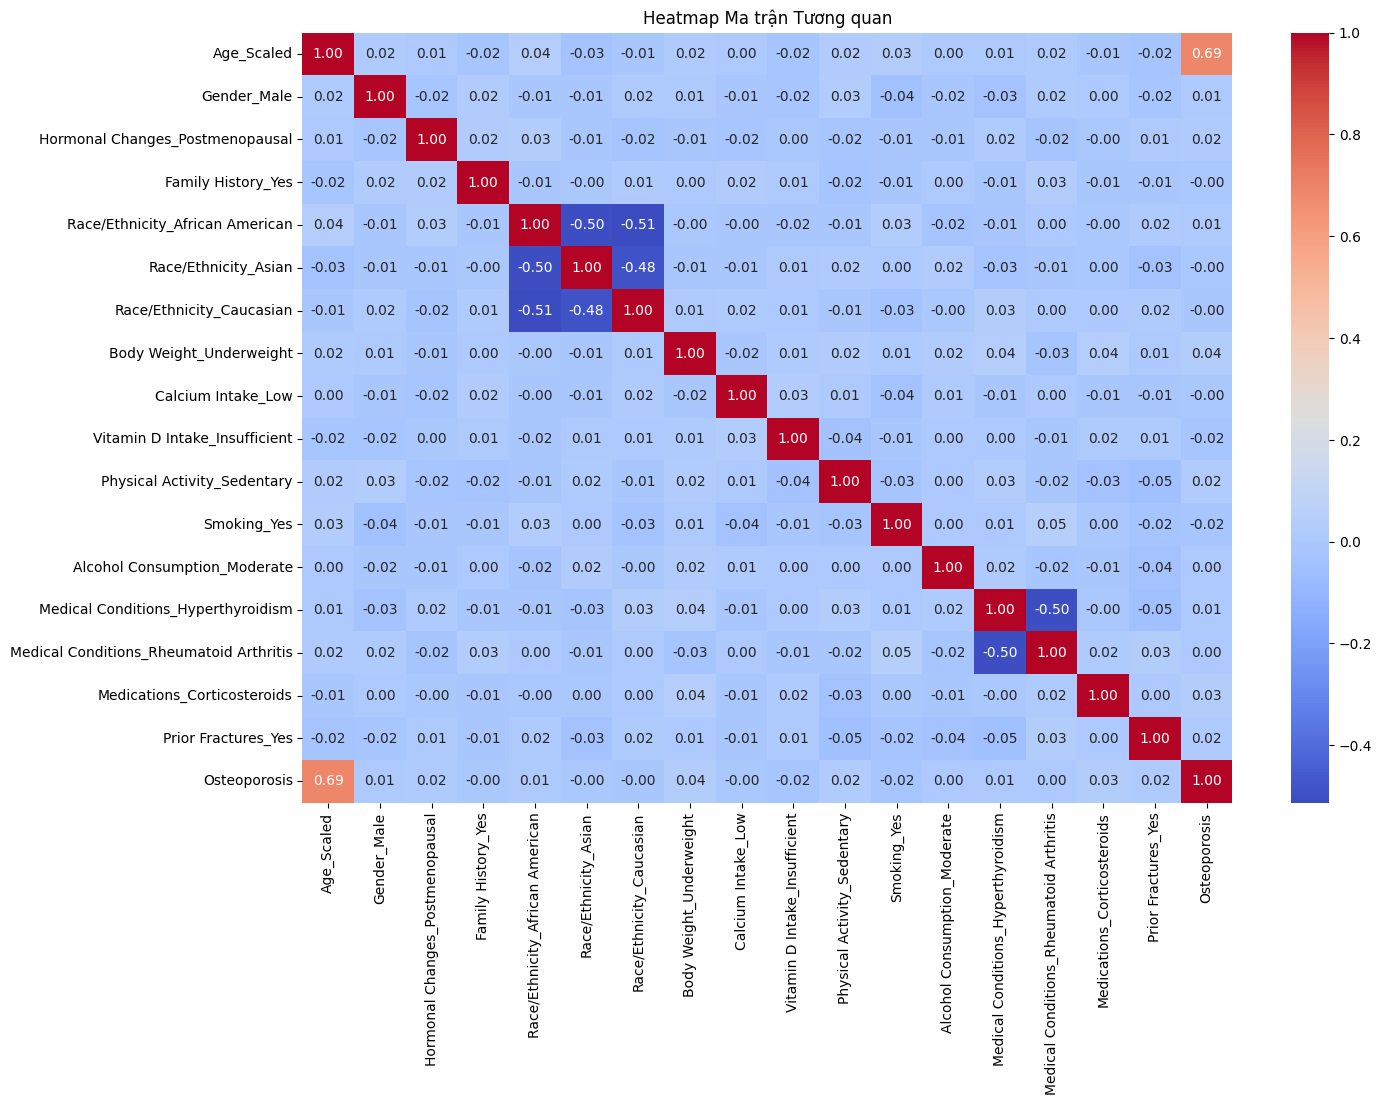

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

# Đặt kích thước biểu đồ cho dễ nhìn
plt.figure(figsize=(15, 10)) 

corr_matrix = data_set_encoded.corr()

# Vẽ heatmap
sns.heatmap(
    corr_matrix, 
    annot=True,     # Hiển thị số lên trên ô
    cmap='coolwarm',  # Dùng thang màu (Đỏ = Dương, Xanh = Âm)
    fmt='.2f'       # Định dạng số (làm tròn 2 chữ số thập phân)
)
plt.title('Heatmap Ma trận Tương quan')
plt.savefig("images/matrix.png")
plt.show()